Project Title: 
A Geospatial Analysis of Facility Functionality in Nigeria
Objectives:
The primary goal of this analysis is to evaluate the distribution and operational health of healthcare infrastructure in Nigeria, using facility data as a proxy for socioeconomic development and health equity. Specifically, this study aims to:

Assess Healthcare Infrastructure Distribution: Analyze the geographic spread of Primary, Secondary, and Tertiary facilities across Nigerian states to identify regions with limited access to specialized care.

Evaluate Operational Functionality as an SES Proxy: Quantify the ratio of "Functional" vs. "Non-Functional" facilities. High rates of non-functional facilities often serve as a proxy for lower socioeconomic status (SES) and systemic underfunding in specific LGAs or States.

Provide Data-Driven Insights for Public Health Policy: Identify priority regions that require immediate infrastructural intervention to improve maternal and chronic disease outcomes, aligning with socioeconomic health determinants.

In [11]:
# Import libraries for data analysis and ceaning
import numpy as np
import pandas as pd

# Import visualization libraries for data visualization
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Loading dataset into a pandas dataframe
df = pd.read_csv('Downloads/ThePortfolio/nigeriahealthfacilities.csv', low_memory=False)

In [14]:
# Display the first few rows of the dataset to understand it structure
df.head()

,id,name,global_id,alternate_name,functional_status,type,ward_code,category,timestamp,accessibility,lga_name,lga_code,state_code,state_name,FID
0,1,G R A Nursing Home,af719462-abfd-4f47-9dc3-0987164e75ac,Nursing Home,Unknown,Primary,12413,Primary Health Center,2020-07-04T13:49:18Z,NaN,Maiduguri,124,BR,Borno,sv_health_facilities.fid--3185df38_17a314b4ee6...
1,2,Gishili Health Center,a29b0328-d844-4358-b0ab-2e120b8fb30f,Nursing Home,Functional,Primary,12413,Primary Health Center,2020-07-04T13:49:18Z,Unknown,Maiduguri,124,BR,Borno,sv_health_facilities.fid--3185df38_17a314b4ee6...
2,3,Lehobi Primary Health Care,b685b769-5c83-4f83-a182-00e7e1b777d8,NaN,Partially Functional,Primary,10207,Primary Health Center,2020-07-04T13:49:18Z,NaN,Askira Uba,102,BR,Borno,sv_health_facilities.fid--3185df38_17a314b4ee6...
3,4,Dugja Idp Camp,78e64f7a-cbb8-4357-9e64-a7e502534527,Mandara Girau Dispensary,Not Functional,Primary,10503,Primary Health Center,2020-07-04T13:49:18Z,Unknown,Biu,105,BR,Borno,sv_health_facilities.fid--3185df38_17a314b4ee6...
4,5,Kopa Maikudiri Dispensary,409c97ce-7490-4dc2-a8f8-2b8d53ad2b12,NaN,Partially Functional,Primary,10209,Dispensary,2020-07-04T13:49:18Z,Unknown,Askira Uba,102,BR,Borno,sv_health_facilities.fid--3185df38_17a314b4ee6...


In [15]:
# Display the last few rows to understand it structure
df.tail()


,id,name,global_id,alternate_name,functional_status,type,ward_code,category,timestamp,accessibility,lga_name,lga_code,state_code,state_name,FID
46141,46604,Lafiya Clinic,350ef859-fe87-440e-ae8e-2272520e242f,NaN,Unknown,Primary,TRSARD05,Primary Health Center,2019-11-15T17:34:16Z,NaN,Ardo-Kola,35001,TA,Taraba,sv_health_facilities.fid--3185df38_17a326f927a...
46142,46605,Ardo Kola Primary Health Care Center,bd59e8e3-80a8-4239-8bbb-4e4c0f648c54,NaN,Functional,Primary,TRSARD02,Primary Health Center,2019-11-15T17:34:16Z,NaN,Ardo-Kola,35001,TA,Taraba,sv_health_facilities.fid--3185df38_17a326f927a...
46143,46606,Ke Comprehensive Health Center,ef14c01b-bc46-4a5c-b61e-4f1634ba5a46,NaN,Unknown,Primary,RVSDEG03,Comprehensive Health Center,2019-11-15T17:29:44Z,NaN,Degema,33008,RI,Rivers,sv_health_facilities.fid--3185df38_17a326f927a...
46144,46607,Bonny Primary Health Center,1e11690d-0a3b-4dbd-b379-8789f350affc,NaN,Functional,Primary,RVSBNY01,Primary Health Center,2019-11-15T17:15:50Z,NaN,Bonny,33007,RI,Rivers,sv_health_facilities.fid--3185df38_17a326f927a...
46145,46608,Ukpe Primary Health Center,3f74184b-589f-4edb-815d-140ff020b456,NaN,Unknown,Primary,ODSIAE08,Primary Health Center,2019-11-15T17:34:16Z,NaN,Ilaje,29010,ON,Ondo,sv_health_facilities.fid--3185df38_17a326f927a...


In [16]:
nRows, nCols = df.shape
print(f' There are {nRows} rows and {nCols} columns in the dataset')

 There are 46146 rows and 15 columns in the dataset


In [23]:
# Check for duplicates
duplicates = df[df.duplicated(subset=['id'], keep='first')]
if not duplicates.empty:
    df_data = df.drop_duplicates(subset=['id'], keep='first').copy()
    print("Duplicates were found and handled")
else:
    df_data= df.copy()
    print("No duplicates found.")
#Display the cleaned dataframe
print("\nCleaned DataFrame")
print(df_data.head()) 

No duplicates found.

Cleaned DataFrame
   id                        name                             global_id  \
0   1          G R A Nursing Home  af719462-abfd-4f47-9dc3-0987164e75ac   
1   2       Gishili Health Center  a29b0328-d844-4358-b0ab-2e120b8fb30f   
2   3  Lehobi Primary Health Care  b685b769-5c83-4f83-a182-00e7e1b777d8   
3   4              Dugja Idp Camp  78e64f7a-cbb8-4357-9e64-a7e502534527   
4   5   Kopa Maikudiri Dispensary  409c97ce-7490-4dc2-a8f8-2b8d53ad2b12   

             alternate_name     functional_status     type ward_code  \
0              Nursing Home               Unknown  Primary     12413   
1              Nursing Home            Functional  Primary     12413   
2                       NaN  Partially Functional  Primary     10207   
3  Mandara Girau Dispensary        Not Functional  Primary     10503   
4                       NaN  Partially Functional  Primary     10209   

                category             timestamp accessibility    lga_name  \


In [26]:
# Data Cleaning: Drop unnecessary columns
columns_to_drop = ['id','global_id', 'alternate_name', 'ward_code', 'accessibility','lga_code', 'state_code', 'FID', 'timestamp']
df_cleaned = df_data.drop(columns_to_drop, axis=1)
df_cleaned.head(6)

,name,functional_status,type,category,lga_name,state_name
0,G R A Nursing Home,Unknown,Primary,Primary Health Center,Maiduguri,Borno
1,Gishili Health Center,Functional,Primary,Primary Health Center,Maiduguri,Borno
2,Lehobi Primary Health Care,Partially Functional,Primary,Primary Health Center,Askira Uba,Borno
3,Dugja Idp Camp,Not Functional,Primary,Primary Health Center,Biu,Borno
4,Kopa Maikudiri Dispensary,Partially Functional,Primary,Dispensary,Askira Uba,Borno
5,Ghumtukum Medical Center,Functional,Primary,Medical Center,Maiduguri,Borno


In [27]:
# Check the data type
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46146 entries, 0 to 46145
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               46146 non-null  object
 1   functional_status  46146 non-null  object
 2   type               46146 non-null  object
 3   category           46112 non-null  object
 4   lga_name           46146 non-null  object
 5   state_name         46146 non-null  object
dtypes: object(6)
memory usage: 2.1+ MB


In [28]:
# Chcking for missing values
df_cleaned.isnull().sum()

name                  0
functional_status     0
type                  0
category             34
lga_name              0
state_name            0
dtype: int64

In [29]:
#Checking for missing rows in the category
df_cleaned[df_cleaned['category'].isnull()]

,name,functional_status,type,category,lga_name,state_name
210,8 Task Force Division Hospital,Functional,Primary Health Clinic,NaN,Monguno,Borno
211,AAH GSSS IDP Camp Clinic,Functional,Primary Health Clinic,NaN,Monguno,Borno
212,ACF NRC IDP Camp Clinic,Functional,Primary Health Center,NaN,Monguno,Borno
213,Ajjari IDP Camp Clinic,Functional,Primary Health Clinic,NaN,Mafa,Borno
214,Alagarno Dispensary,Functional,Health Post Dispensary,NaN,Askira Uba,Borno
215,Ayi Yasku Dispensary,Not Functional,Health Post Dispensary,NaN,Magumeri,Borno
216,Bakassi IDP Camp Clinic,Functional,Primary Health Center,NaN,Monguno,Borno
217,Bera Dispensary,Functional,Health Post Dispensary,NaN,Biu,Borno
218,Boarding Primary School IDP Camp Clinic,Functional,Primary Health Clinic,NaN,Konduga,Borno
221,Dabar Masara Health Clinic,Not Functional,Health Post Dispensary,NaN,Kukawa,Borno


In [30]:
# Create a new category label for missing values
missing_category_label = "Unknown"

# Replace missing values in the 'category' column with the new label
df_cleaned['category'] = df_cleaned['category'].fillna(missing_category_label)

df_cleaned.isnull().sum()

name                 0
functional_status    0
type                 0
category             0
lga_name             0
state_name           0
dtype: int64

In [32]:
#Summary of all the statistics
print (df_cleaned.describe(include ='all'))

                 name functional_status     type               category  \
count           46146             46146    46146                  46146   
unique          43292                 4        7                     22   
top     Police Clinic        Functional  Primary  Primary Health Center   
freq               17             34282    43970                  28031   

       lga_name state_name  
count     46146      46146  
unique      769         37  
top         Ifo      Lagos  
freq        226       2320  


Q1: Facility Distribution: How are healthcare facilities distributed across Nigeria's 36 states? Are there any states with a significantly higher or lower number of facilities?

In [33]:
# Question 1: How many facilities of each type per state?
q1_counts = pd.crosstab(df_cleaned['state_name'], df['type'])
print(q1_counts.head())

type        Health Post Dispensary  Primary  Primary Health Center  \
state_name                                                           
Abia                             0     1160                      0   
Adamawa                          0     1546                      0   
Akwa Ibom                        0      811                      0   
Anambra                          0     1494                      0   
Bauchi                           0     1305                      0   

type        Primary Health Clinic  Secondary  Tertiary  Unknown  
state_name                                                       
Abia                            0         27        31        0  
Adamawa                         0         26         3        0  
Akwa Ibom                       0         34        25        0  
Anambra                         0         44       110        0  
Bauchi                          0         25         1        0  


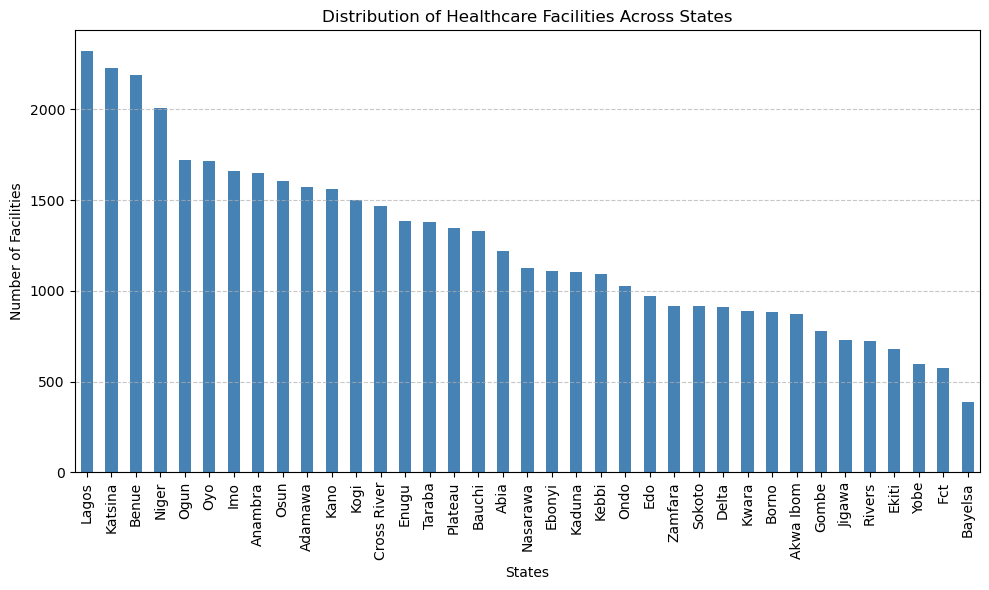

In [36]:


# Plot the distribution of facility counts across states
plt.figure(figsize=(10, 6))
facility_counts.plot(kind='bar', color='steelblue')
plt.xlabel('States')
plt.ylabel('Number of Facilities')
plt.title('Distribution of Healthcare Facilities Across States')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [38]:
# Calculate Percentages:
facility_counts = df_cleaned['state_name'].value_counts()
facility_percentages = (facility_counts / facility_counts.sum() * 100).round(2)

# Append the % sign
facility_percentages = facility_percentages.astype(str) + '%'
print (facility_percentages)

state_name
Lagos          5.03%
Katsina        4.83%
Benue          4.75%
Niger          4.36%
Ogun           3.73%
Oyo            3.71%
Imo             3.6%
Anambra        3.57%
Osun           3.48%
Adamawa        3.41%
Kano           3.38%
Kogi           3.25%
Cross River    3.19%
Enugu           3.0%
Taraba         2.99%
Plateau        2.92%
Bauchi         2.88%
Abia           2.64%
Nasarawa       2.44%
Ebonyi         2.41%
Kaduna         2.39%
Kebbi          2.36%
Ondo           2.22%
Edo            2.11%
Zamfara        1.99%
Sokoto         1.98%
Delta          1.97%
Kwara          1.93%
Borno          1.92%
Akwa Ibom      1.89%
Gombe          1.68%
Jigawa         1.58%
Rivers         1.57%
Ekiti          1.47%
Yobe           1.29%
Fct            1.25%
Bayelsa        0.84%
Name: count, dtype: object


In [39]:
# Calculate total and specialized counts
q1_counts['Total'] = q1_counts.sum(axis=1)
q1_counts['Specialized_Care'] = q1_counts.get('Secondary', 0) + q1_counts.get('Tertiary', 0)

#  Q2 : What is the specialized care ratio per state?
# Calculate the ratio as a percentage
q1_counts['Specialized_Ratio_%'] = (q1_counts['Specialized_Care'] / q1_counts['Total']) * 100
print(q1_counts[['Total', 'Specialized_Ratio_%']].head())

type        Total  Specialized_Ratio_%
state_name                            
Abia         1218             4.761905
Adamawa      1575             1.841270
Akwa Ibom     870             6.781609
Anambra      1648             9.344660
Bauchi       1331             1.953418


In [40]:
# Question 3: Which states have the most limited access to specialized care?
# Sort by the ratio in ascending order (lowest first)
q3_outliers = q1_counts.sort_values('Specialized_Ratio_%', ascending=True)

# Show the bottom 5 states (the "Outliers" with the least specialized care)
print(q3_outliers[['Specialized_Ratio_%']].head())

type        Specialized_Ratio_%
state_name                     
Katsina                1.122083
Taraba                 1.594203
Kaduna                 1.631913
Adamawa                1.841270
Bauchi                 1.953418


In [41]:
# What is the operational status breakdown of all facilities?
# Global breakdown of operational status
global_status = df_cleaned['functional_status'].value_counts(normalize=True) * 100
print(global_status)

functional_status
Functional              74.290296
Unknown                 25.469163
Not Functional           0.225372
Partially Functional     0.015169
Name: proportion, dtype: float64


In [43]:
# Which geographic units have the highest concentration of non-functional facilities?"
# Calculate functionality rate per state
state_func = pd.crosstab(df['state_name'], df_cleaned['functional_status'])
state_func['Total'] = state_func.sum(axis=1)

# Focus on the 'Functional' percentage
state_func['Functionality_Rate_%'] = (state_func['Functional'] / state_func['Total']) * 100

# Sort to find regions with the highest operational failure (Lowest SES Proxy)
ses_proxy_ranking = state_func.sort_values('Functionality_Rate_%', ascending=True)
print(ses_proxy_ranking[['Total', 'Functionality_Rate_%']].head())

functional_status  Total  Functionality_Rate_%
state_name                                    
Plateau             1348             38.056380
Yobe                 597             40.536013
Zamfara              916             44.213974
Adamawa             1575             44.380952
Kebbi               1091             44.729606


In [44]:
# How much of the operational data is missing or 'Unknown'?
# Which states have the most 'Unknown' data?
state_func['Unknown_Rate_%'] = (state_func['Unknown'] / state_func['Total']) * 100

# Rank states by highest 'Unknown' percentage
data_gaps = state_func.sort_values('Unknown_Rate_%', ascending=False)
print(data_gaps[['Unknown', 'Unknown_Rate_%']].head())

functional_status  Unknown  Unknown_Rate_%
state_name                                
Plateau                835       61.943620
Yobe                   355       59.463987
Zamfara                511       55.786026
Kebbi                  603       55.270394
Adamawa                865       54.920635


C:\Users\USER\AppData\Local\Temp\ipykernel_19180\3842043263.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, y='category', palette='magma')


Text(0.5, 1.0, 'Infrastructure Service Levels')

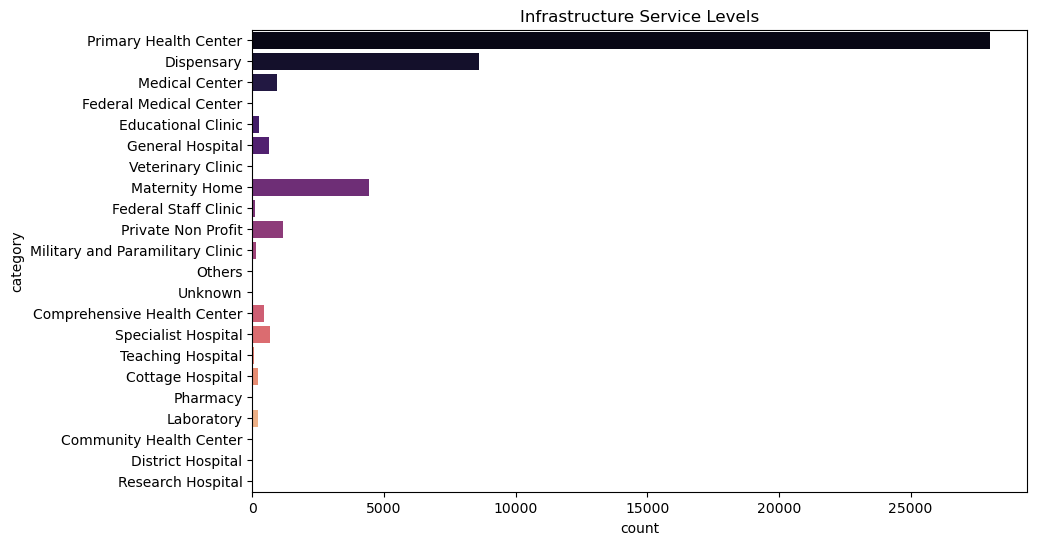

In [49]:
# Distribution of Categories
plt.figure(figsize=(10,6))
sns.countplot(data=df_cleaned, y='category', palette='magma')
plt.title('Infrastructure Service Levels')

In [50]:
# Which regions have the highest availability of specialized infrastructure?
# Identify advanced development (Hospitals and Teaching Centers)
advanced_care = ['Teaching Hospital', 'Specialist Hospital', 'General Hospital']
ownership_dist['Advanced_Ratio'] = (ownership_dist[advanced_care].sum(axis=1) / ownership_dist.sum(axis=1)) * 100
print(ownership_dist['Advanced_Ratio'].sort_values(ascending=False).head())

state_name
Anambra    7.038835
Rivers     6.085754
Lagos      5.948276
Delta      5.500550
Ekiti      5.449190
Name: Advanced_Ratio, dtype: float64


In [52]:
# Which states have the lowest number of facilities designated as 'Tertiary' infrastructure?
# Filter for highest-tier healthcare categories
tertiary_cats = ['Teaching Hospital', 'Specialist Hospital', 'Federal Medical Center']
tertiary_data = df[df['category'].isin(tertiary_cats)]

# Count these facilities per state
tertiary_counts = tertiary_data.groupby('state_name').size().sort_values()

# Identify states with very low specialized infrastructure
print(tertiary_counts.head(10))

state_name
Bauchi     2
Katsina    2
Taraba     2
Yobe       3
Zamfara    3
Kogi       4
Gombe      4
Adamawa    4
Jigawa     4
Kebbi      4
dtype: int64


In [58]:
# Which states fall below the 50% functionality threshold while also lacking secondary/tertiary facilities?
# Build the state-level summary (The 'state_func' table)
state_func = pd.crosstab(df_cleaned['state_name'], df_cleaned['functional_status'])
state_func['Total'] = state_func.sum(axis=1)
state_func['Functionality_Rate'] = (state_func['Functional'] / state_func['Total']) * 100

# 3. Add specialized facility counts
state_specialized = df[df['type'].isin(['Secondary', 'Tertiary'])].groupby('state_name').size()
state_func['Specialized_Facilities'] = state_specialized.reindex(state_func.index, fill_value=0)

# 4. Run the Priority Logic
median_spec = state_func['Specialized_Facilities'].median()
priority_list = state_func[(state_func['Functionality_Rate'] < 50) & 
                           (state_func['Specialized_Facilities'] < median_spec)]

print("Policy Priority States (Low Functionality & Low Capacity):")
print(priority_list.index.tolist())

Policy Priority States (Low Functionality & Low Capacity):
['Adamawa', 'Kebbi', 'Plateau', 'Yobe', 'Zamfara']


In [61]:
# Which regions have the lowest count of "Maternity Homes" and "Comprehensive Health Centers" relative to their population or total facility count?
# Categorize maternal care availability
maternal_data = df_cleaned[df_cleaned['category'] == 'Maternity Home'].groupby('state_name').size()
print(maternal_data.sort_values().head(3))

state_name
Jigawa     2
Sokoto     2
Zamfara    3
dtype: int64


In [62]:
# In states identified as socioeconomic outliers, how many Tertiary facilities are actually functional?
# 1. Filter specifically for Tertiary facilities
tertiary_df = df[df['type'] == 'Tertiary']

# 2. Analyze functional status within this specialized group
tertiary_func = pd.crosstab(tertiary_df['state_name'], tertiary_df['functional_status'])

# 3. Calculate the functionality rate for these high-tier centers
tertiary_func['Total_Tertiary'] = tertiary_func.sum(axis=1)
tertiary_func['Functional_Rate_%'] = (tertiary_func['Functional'] / tertiary_func['Total_Tertiary']) * 100

# 4. Identify critical barriers (States with low counts AND low functionality)
critical_barriers = tertiary_func[tertiary_func['Total_Tertiary'] <= 5].sort_values('Functional_Rate_%')

print("States with Critical Chronic Disease Management Barriers:")
print(critical_barriers[['Total_Tertiary', 'Functional', 'Functional_Rate_%']])

States with Critical Chronic Disease Management Barriers:
functional_status  Total_Tertiary  Functional  Functional_Rate_%
state_name                                                      
Katsina                         2           1          50.000000
Taraba                          2           1          50.000000
Kebbi                           3           2          66.666667
Adamawa                         3           3         100.000000
Jigawa                          3           3         100.000000
Bauchi                          1           1         100.000000
Kogi                            3           3         100.000000
Nasarawa                        4           4         100.000000
Yobe                            2           2         100.000000
Zamfara                         2           2         100.000000


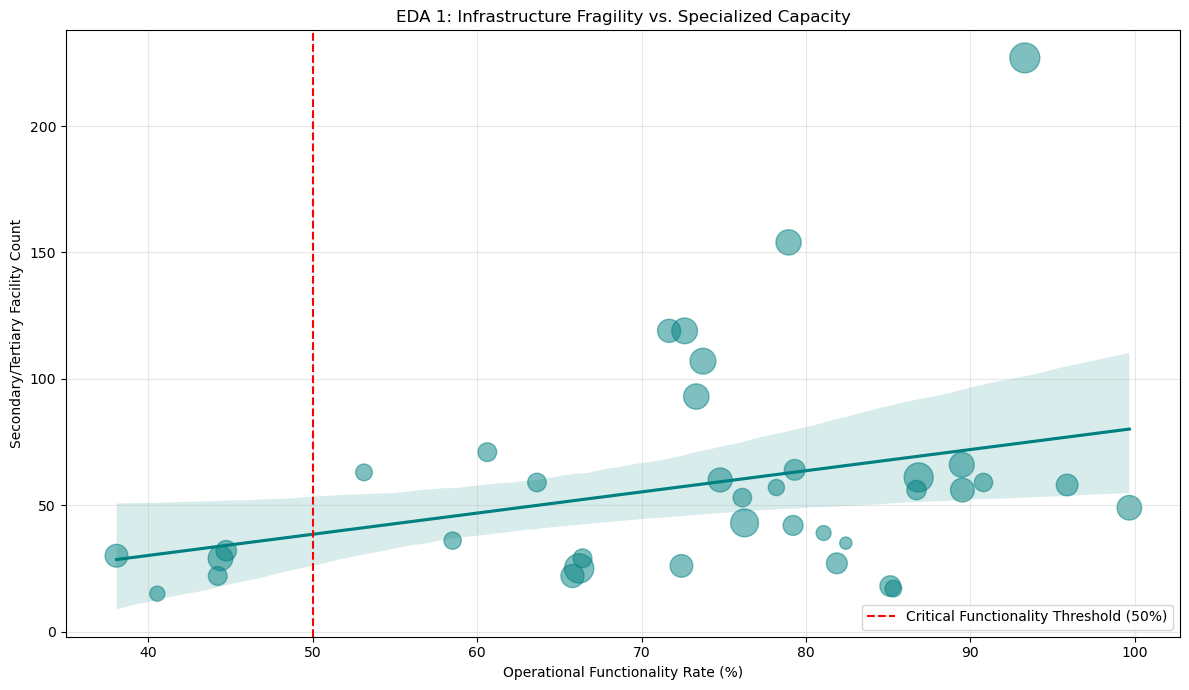

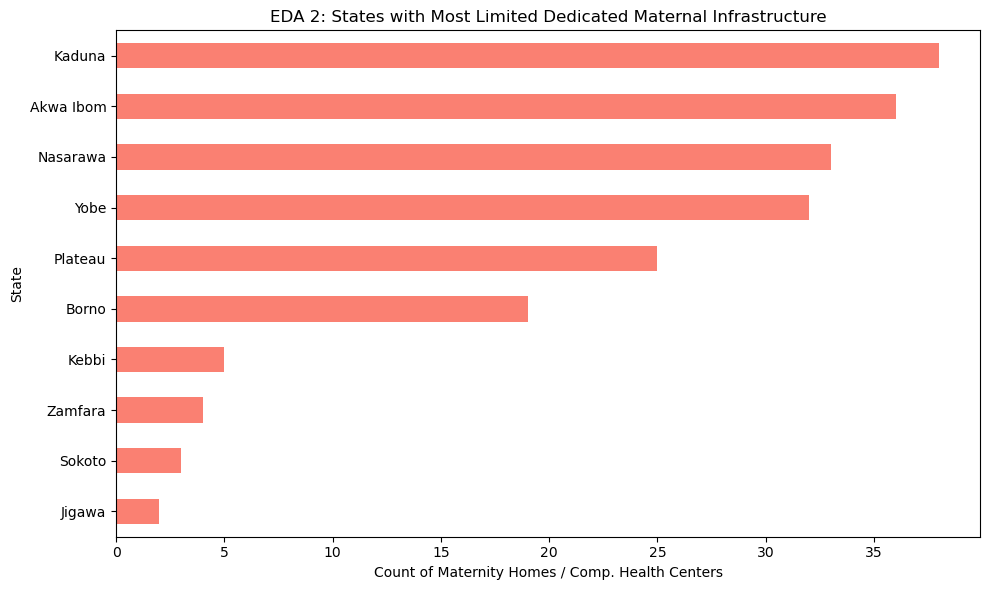

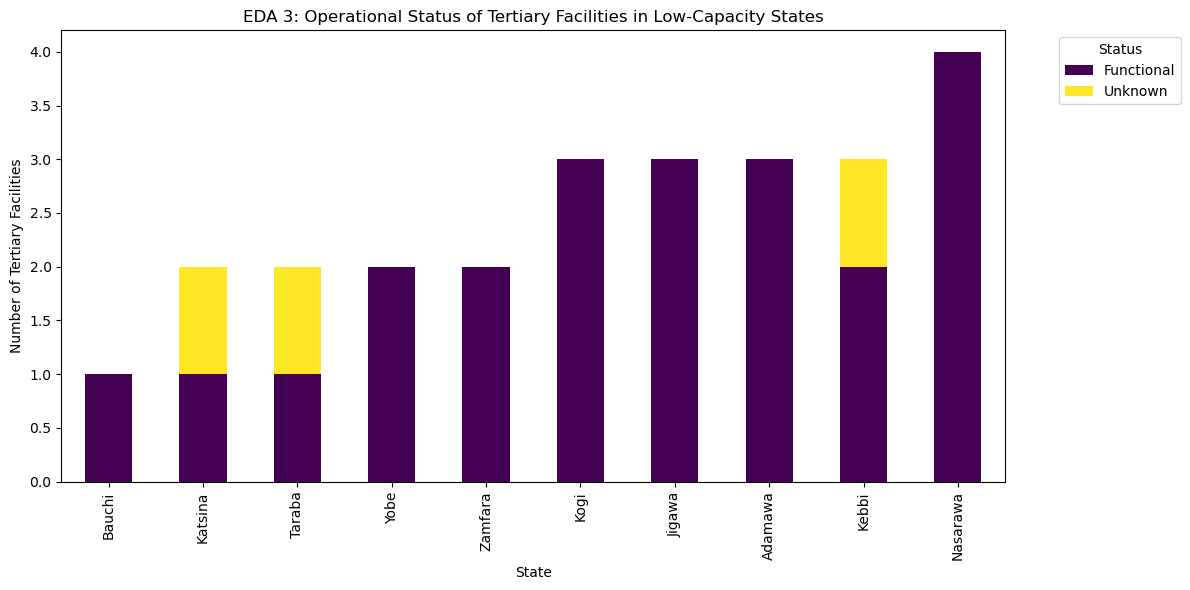

In [64]:
# --- 1. DATA PRE-PROCESSING ---
# Building a state-level summary table to analyze functionality and capacity
state_func = pd.crosstab(df_cleaned['state_name'], df_cleaned['functional_status'])
state_func['Total'] = state_func.sum(axis=1)
state_func['Functionality_Rate'] = (state_func['Functional'] / state_func['Total']) * 100

# Quantifying Specialized Care (Secondary + Tertiary levels)
state_specialized = df_cleaned[df_cleaned['type'].isin(['Secondary', 'Tertiary'])].groupby('state_name').size()
state_func['Specialized_Count'] = state_specialized.reindex(state_func.index, fill_value=0)

# Quantifying Dedicated Maternal Infrastructure
maternal_cats = ['Maternity Home', 'Comprehensive Health Center']
state_maternal = df_cleaned[df_cleaned['category'].isin(maternal_cats)].groupby('state_name').size()
state_func['Maternal_Count'] = state_maternal.reindex(state_func.index, fill_value=0)


# ---  EDA 1: RISK STRATIFICATION ---
# Visualizing the relationship between operational health and specialized capacity
plt.figure(figsize=(12, 7))
sns.regplot(data=state_func, x='Functionality_Rate', y='Specialized_Count', 
            scatter_kws={'s': state_func['Total']/5, 'alpha':0.5}, color='teal')
plt.axvline(x=50, color='red', linestyle='--', label='Critical Functionality Threshold (50%)')
plt.title('EDA 1: Infrastructure Fragility vs. Specialized Capacity')
plt.xlabel('Operational Functionality Rate (%)')
plt.ylabel('Secondary/Tertiary Facility Count')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# --- EDA 2: MATERNAL HEALTH VOIDS ---
# Ranking states with the most limited maternal infrastructure
maternal_bottom = state_func['Maternal_Count'].sort_values().head(10)
plt.figure(figsize=(10, 6))
maternal_bottom.plot(kind='barh', color='salmon')
plt.title('EDA 2: States with Most Limited Dedicated Maternal Infrastructure')
plt.xlabel('Count of Maternity Homes / Comp. Health Centers')
plt.ylabel('State')
plt.tight_layout()
plt.show()


# --- EDA 3: TERTIARY OPERATIONAL RELIABILITY ---
# Analyzing high-tier centers in states with limited capacity
tertiary_df_cleaned = df_cleaned[df_cleaned['type'] == 'Tertiary']
tertiary_status = pd.crosstab(tertiary_df_cleaned['state_name'], tertiary_df_cleaned['functional_status'])

# Focusing on the bottom 10 states by tertiary capacity
low_t_states = tertiary_status.sum(axis=1).sort_values().head(10).index
tertiary_status_subset = tertiary_status.loc[low_t_states]

tertiary_status_subset.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('EDA 3: Operational Status of Tertiary Facilities in Low-Capacity States')
plt.xlabel('State')
plt.ylabel('Number of Tertiary Facilities')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()